In [1]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer() 
from nltk.corpus import wordnet
from collections import Counter
import itertools

In [2]:
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

df = pd.read_csv('Sentiment_Labelled_CommentsV3.csv')

tiktok_ban_comments = df[df['Cleaned_Comment_v2'].str.contains('tiktok', case=False) &
                         df['Cleaned_Comment_v2'].str.contains('ban', case=False)]
# Convert to datetime type
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601')
df['Date'] = df['Date'].dt.date         

# Filter data within a specified time range
start_date = pd.to_datetime('2024-12-03').date()
end_date = pd.to_datetime('2025-04-13').date()
df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# Statistics of topic popularity (number of comments) by date
daily_counts = df.groupby('Date').size().sort_index()  

# Calculate the sentiment ratio
sentiment_proportions = df.groupby(['Date', 'Sentiment']).size().unstack(fill_value=0)
sentiment_proportions = sentiment_proportions.div(sentiment_proportions.sum(axis=1), axis=0).sort_index()  



In [3]:
#Calculate the number of sentiment trends 
sentiment_counts = df.groupby(['Date', 'Sentiment']).size().unstack(fill_value=0).sort_index()


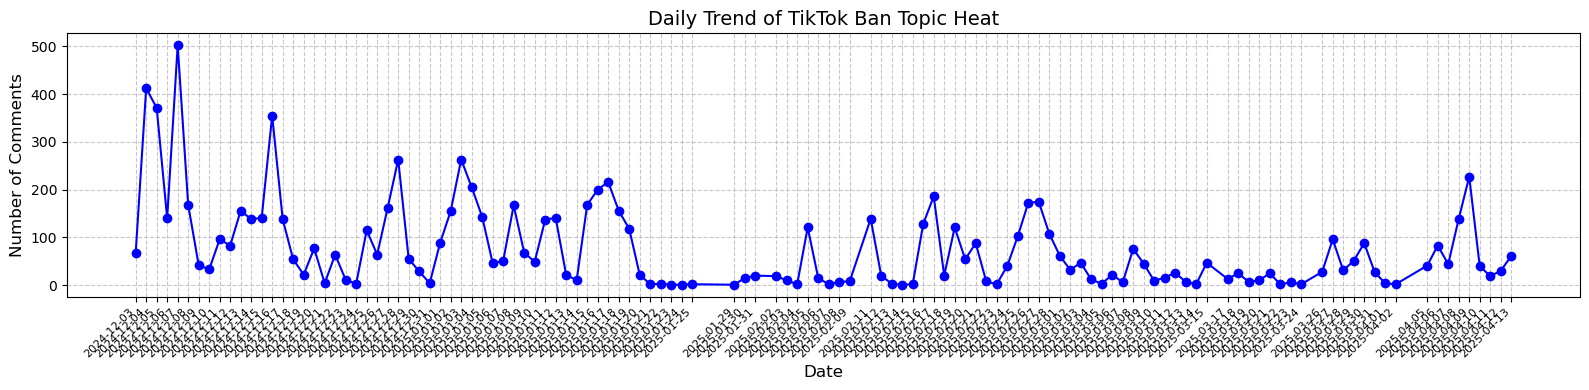

In [4]:
# Draw trend chart
plt.figure(figsize=(16, 4))  

# chart 1
ax1 = plt.subplot()
ax1.plot(daily_counts.index, daily_counts.values, marker='o', color='blue', linewidth=1.5)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Number of Comments', fontsize=12)
ax1.set_title('Daily Trend of TikTok Ban Topic Heat', fontsize=14)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)

ax1.set_xticks(daily_counts.index)  
plt.setp(ax1.get_xticklabels(), ha='right', fontsize=8)  

plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))  
plt.tight_layout()  
plt.show()



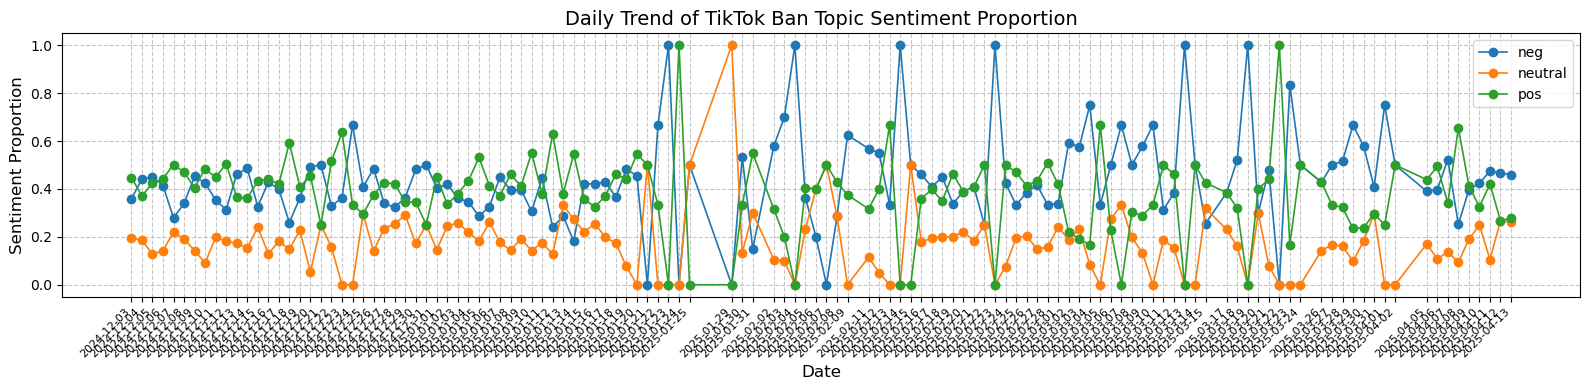

In [5]:
plt.figure(figsize=(16, 4)) 

# chart 2
ax2 = plt.subplot()
for sentiment in sentiment_proportions.columns:
    ax2.plot(sentiment_proportions.index, sentiment_proportions[sentiment], marker='o', linewidth=1.2, label=sentiment)
ax2.set_xlabel('Date', fontsize=12)
ax2.set_ylabel('Sentiment Proportion', fontsize=12)
ax2.set_title('Daily Trend of TikTok Ban Topic Sentiment Proportion', fontsize=14)
ax2.tick_params(axis='x', rotation=45)


ax2.set_xticks(daily_counts.index)  
plt.setp(ax2.get_xticklabels(), ha='right', fontsize=8)  

ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))  
plt.tight_layout()  
plt.show()

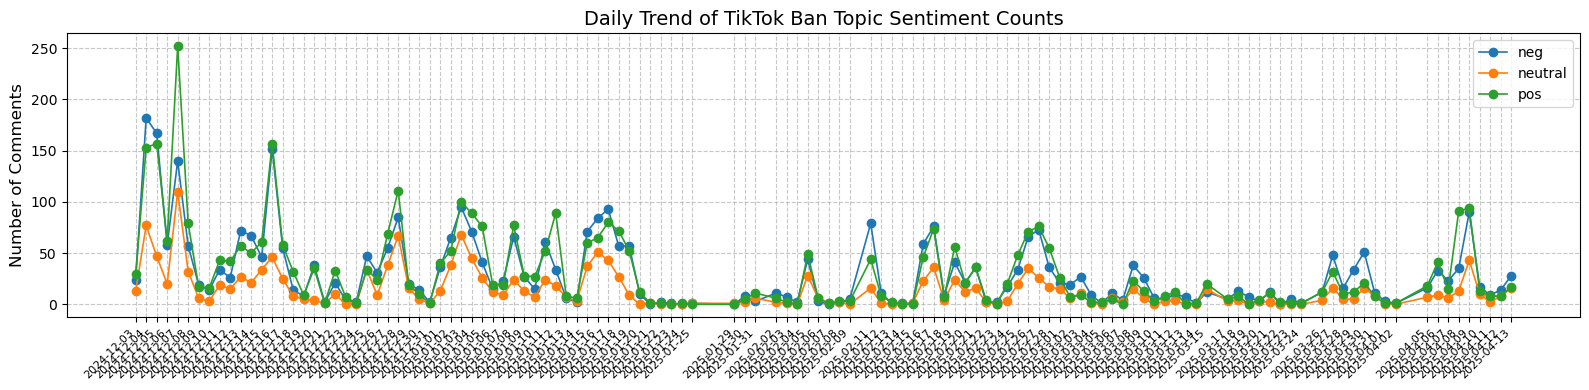

In [6]:
# chart 3
plt.figure(figsize=(16, 4)) 

ax3 = plt.subplot()
for sentiment in sentiment_counts.columns:
    ax3.plot(sentiment_counts.index, sentiment_counts[sentiment], marker='o', linewidth=1.2, label=sentiment)
ax2.set_xlabel('Date', fontsize=12)
ax3.set_ylabel('Number of Comments', fontsize=12)
ax3.set_title('Daily Trend of TikTok Ban Topic Sentiment Counts', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
plt.setp(ax3.get_xticklabels(), ha='right', fontsize=8)

ax3.set_xticks(daily_counts.index) 
plt.setp(ax3.get_xticklabels(), ha='right', fontsize=8)  
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.7)


plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
plt.tight_layout() 
plt.show()
